***
<center><h1> Marine Heatwaves along the Southern Coast of Java </h1></center>

Marine heatwaves (MHWs) are defined as prolonged, discrete periods of anomalously warm sea surface temperatures (SST) that exceed the local 90th percentile threshold for at least five consecutive days (Hobday et al., 2016). Over recent decades, anthropogenic climate change has accelerated global ocean warming, leading to a significant increase in MHW frequency, duration, and intensity worldwide. These extreme thermal events induce severe ecological and socio-economic consequences, such as coral bleaching, mass mortality of marine organisms, shifts in species distribution, and disruptions to local fisheries.

In Indonesian waters, SST has been warming at an average rate of $0.19 \pm 0.04^\circ\text{C}$ per decade (1982–2014), surpassing the global average warming trend of $0.13^\circ\text{C}$ per decade (Iskandar et al., 2020; Beliyana et al., 2023). Among various oceanic sub-regions in Indonesia, the **Southern Coast of Java (South Java)** stands out as an oceanographically critical zone. This region is characterized by strong seasonal coastal upwelling during the Southeast Monsoon (June–August), which brings cool, nutrient-rich water to the surface and supports highly productive fishing grounds for tuna (Syamsuddin et al., 2016; Ningsih et al., 2025).

However, South Java is also highly vulnerable to intense MHWs driven by both local air-sea heat fluxes, heat advection via the Indonesian Throughflow (ITF), and climate modes like the El Niño-Southern Oscillation (ENSO) and the Indian Ocean Dipole (IOD) (Beliyana et al., 2023; Ningsih et al., 2025). Extreme MHWs in this area can suppress seasonal upwelling, disrupt primary productivity (chlorophyll-$a$), and threaten regional marine biodiversity.

In this tutorial, we will analyze high-resolution OSTIA SST data off South Java to detect MHW events, calculate climatological baselines, categorize event intensities, and examine multi-decadal MHW metrics.

To run this notebook smoothly, make sure you have installed all essential packages

In [4]:
# To avoid warning messages
import warnings

warnings.filterwarnings("ignore")

# Import libraries
import datetime
import glob
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as colors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import ListedColormap
from scipy.ndimage import label
import copernicusmarine

Download Dataset

In [5]:
copernicusmarine.login()

INFO - 2026-08-26T06:22:44Z - Using existing credentials from C:\Users\muham\.copernicusmarine\.copernicusmarine-credentials. Use --force-overwrite combined with credentials (specified by arguments, netrc file or environment variables) to always overwrite.


True

In [6]:
# Define output directory and file details
output_dir = "./data" # directory downloaded data
output_file = "cmems_sst_ostia_jawa.nc" # filename
dataset_id_to_retrieve = "METOFFICE-GLO-SST-L4-REP-OBS-SST" #copernicus dataset id that we want to download

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

print("Starting subset and download process...")

# Download subsetted NetCDF file
copernicusmarine.subset(
    dataset_id=dataset_id_to_retrieve,
    variables=["analysed_sst"],
    minimum_longitude=105.0,
    maximum_longitude=160,
    minimum_latitude=-9.5,
    maximum_latitude=-7.5,
    start_datetime="1982-01-01T00:00:00",
    end_datetime="2012-12-31T00:00:00",
    output_filename=output_file,
    output_directory=output_dir,
    #username=USERNAME,
    #password=PASSWORD,
    force_download=True,  # Parameter yang diperbarui untuk menimpa file lama
)

print(f"Download completed! File saved at: {output_dir}/{output_file}")

WARNING - 2026-08-26T06:22:51Z - 'force_download' has been deprecated.


Starting subset and download process...


INFO - 2026-08-26T06:23:02Z - Selected dataset version: "202003"
INFO - 2026-08-26T06:23:02Z - Selected dataset part: "default"
100%|██████████| [03:15<00:00]  
INFO - 2026-08-26T06:26:31Z - Total size of the download: 950.80 MB.


Download completed! File saved at: ./data/cmems_sst_ostia_jawa.nc


In [7]:
# Path to local dataset
data_path = "./data/cmems_sst_ostia_jawa.nc"

# Open dataset using xarray
ds = xr.open_dataset(data_path)

# Convert SST from Kelvin to Celsius if necessary
if float(ds["analysed_sst"].mean()) > 100:
    ds["analysed_sst"] = ds["analysed_sst"] - 273.15

ds

<xarray.Dataset> Size: 4GB
Dimensions:       (time: 11323, latitude: 40, longitude: 1100)
Coordinates:
  * time          (time) datetime64[ns] 91kB 1982-01-01 ... 2012-12-31
  * latitude      (latitude) float32 160B -9.475 -9.425 -9.375 ... -7.575 -7.525
  * longitude     (longitude) float32 4kB 105.0 105.1 105.1 ... 159.9 160.0
Data variables:
    analysed_sst  (time, latitude, longitude) float64 4GB 28.52 28.5 ... 29.75
Attributes: (12/48)
    Conventions:                CF-1.4, ACDD-1.3
    Metadata_Conventions:       Unidata Observation Dataset v1.0
    acknowledgment:             Please acknowledge the use of these data with...
    cdm_data_type:              grid
    comment:                    WARNING Some applications are unable to prope...
    creator_email:              servicedesk.cmems@mercator-ocean.eu
    ...                         ...
    time_coverage_end:          19811002T000000Z
    time_coverage_start:        19811001T000000Z
    title:                      Global SST & Sea Ice Analysis, L4 OSTIA, 0.05...
    uuid:                       a2df4a18-6f19-4772-9532-39307a0e2794
    westernmost_longitude:      -180.0
    copernicusmarine_version:   2.4.1

Let's visualize the spatial distribution of Sea Surface Temperature off South Java on a specific date (e.g., during the 2016 strong El Niño / MHW event).

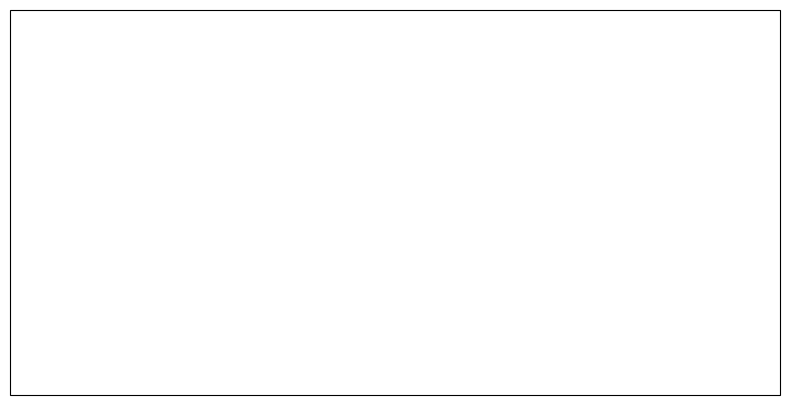

In [29]:
# Choose a date during a known warm anomaly / MHW event
t_plot = "1998-03-01"

# Extract single time step
ds_single = ds.sel(time=t_plot, method="nearest")

# Setup Figure & Cartopy Axis
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())



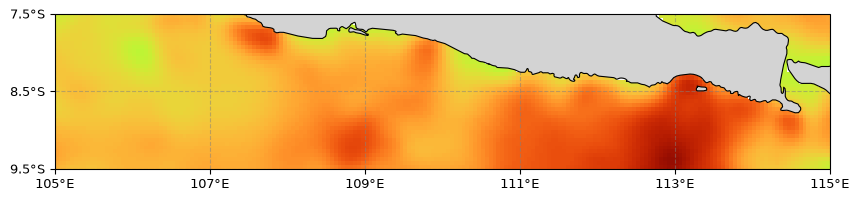

In [30]:
# Define geographical bounding box for South Java (SJ)
lon_min, lon_max = 105.0, 115.0
lat_min, lat_max = -9.5, -7.5

# Add Geographic Features
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5, zorder=3)

# Set map boundaries
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# # Gridlines
# gl = ax.gridlines(
#     crs=ccrs.PlateCarree(), draw_labels=True, linestyle="--", alpha=0.5
# )
# gl.top_labels = False
# gl.right_labels = False

# Drawing the Grid Lines
xticks = [105, 107, 109, 111, 113, 115]
yticks = [-9.5, -8.5, -7.5]

ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, color='gray')

ax.set_xticklabels([f"{x}°E" for x in xticks], fontsize=9)
ax.set_yticklabels([f"{abs(y)}°S" for y in yticks], fontsize=9)

# Plotting the Temperature Data
im = ax.pcolormesh(
    ds_single["longitude"], 
    ds_single["latitude"], 
    ds_single["analysed_sst"], 
    cmap="turbo",
    vmin=26,
    vmax=32,
    shading="auto",            
    transform=ccrs.PlateCarree(),
    zorder=1,
)

fig

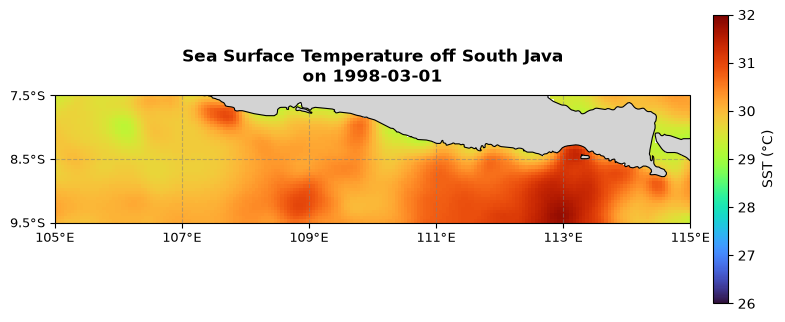

<Figure size 640x480 with 0 Axes>

In [31]:
# Colorbar & Title
cbar = plt.colorbar(
    im, ax=ax, label="SST (°C)", shrink=0.75, pad=0.03, orientation="vertical"
)
ax.set_title(
    f"Sea Surface Temperature off South Java\non {t_plot}",
    fontsize=12,
    fontweight="bold",
    pad=10,
)

fig

Computing temperature trends

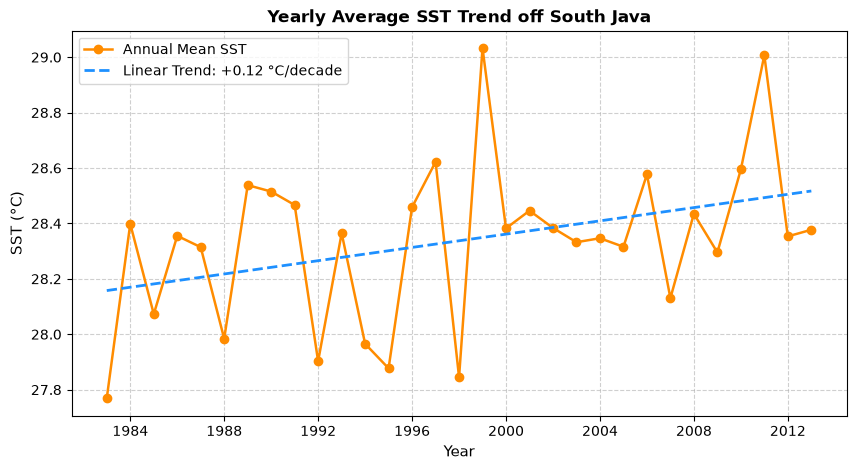

In [24]:
# 1. Compute spatial average over South Java
ds_spatial_mean = ds["analysed_sst"].mean(dim=["longitude", "latitude"])

# 2. Resample to annual mean
ds_yearly = ds_spatial_mean.resample(time="1YE").mean().compute()

# 3. Linear Regression setup
time_years = ds_yearly["time.year"].data
sst_yearly_vals = ds_yearly.data

# Convert time to numeric days relative to start year for precise fitting
days_from_start = (
    ds_yearly["time"].data - ds_yearly["time"].data[0]
) / np.timedelta64(1, "D")
slope, intercept = np.polyfit(days_from_start, sst_yearly_vals, 1)

# Calculate trend line and decadal rate
trend_line = slope * days_from_start + intercept
decadal_trend = slope * 365.25 * 10  # °C per decade

# 4. Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    ds_yearly["time"],
    sst_yearly_vals,
    color="darkorange",
    marker="o",
    linewidth=1.8,
    label="Annual Mean SST",
)
ax.plot(
    ds_yearly["time"],
    trend_line,
    color="dodgerblue",
    linestyle="--",
    linewidth=2,
    label=f"Linear Trend: +{decadal_trend:.2f} °C/decade",
)

ax.set_title(
    "Yearly Average SST Trend off South Java", fontsize=12, fontweight="bold"
)
ax.set_ylabel("SST (°C)", fontsize=11)
ax.set_xlabel("Year", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="upper left")

plt.show()

Observing Marine Heatwaves

In [25]:
# climatologies :

# baseline period : 1982-2011

ds_clim_avg = ds["analysed_sst"].sel(time=slice("1982", "2011")).mean(dim=["time"])
ds_clim_90p = (
    ds["analysed_sst"]
    .sel(time=slice("1982", "2011"))
    .quantile(dim=["time"], q=0.9)
)

In [26]:
ds_clim_avg_ts = (
    ds["analysed_sst"]
    .sel(time=slice("1982", "2011"))
    .mean(dim=["longitude", "latitude"])
    .groupby("time.dayofyear")
    .mean()
    .sel(dayofyear=slice(1, 365))
)
ds_clim_90p_ts = (
    ds["analysed_sst"]
    .sel(time=slice("1982", "2011"))
    .mean(dim=["longitude", "latitude"])
    .groupby("time.dayofyear")
    .quantile(q=0.9)
    .sel(dayofyear=slice(1, 365))
)

# smoothing
ds_clim_avg_ts = ds_clim_avg_ts.rolling(
    dayofyear=10, center=True, min_periods=1
).mean()
ds_clim_90p_ts = ds_clim_90p_ts.rolling(
    dayofyear=10, center=True, min_periods=1
).mean()

We now have a baseline to which we can compare actual observations, year by year. Let's visualize an example.

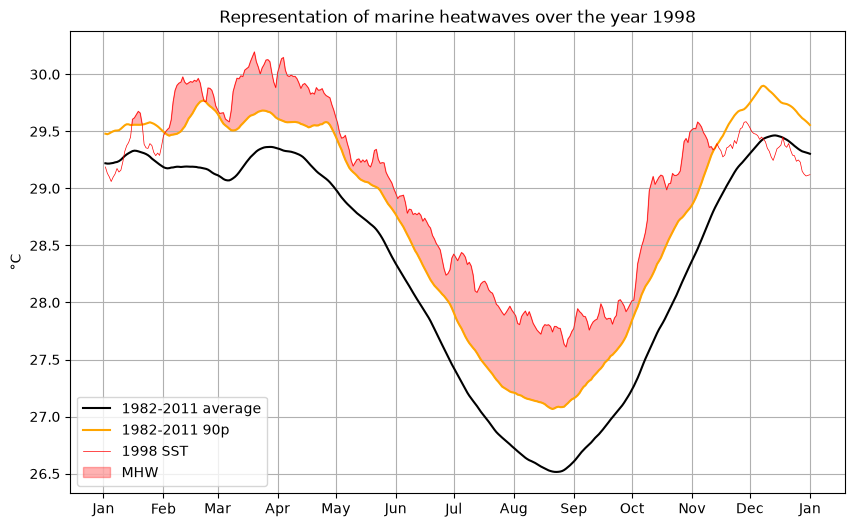

In [27]:
# choose year to analyse
year = 1998

fig, ax = plt.subplots(figsize=(10, 6))

ds_ts = ds.mean(dim=["longitude", "latitude"])

dates = ds_clim_avg_ts.dayofyear.data
sst = (
    ds_ts.sel(time=str(year))
    .groupby("time.dayofyear")
    .mean()
    .sel(dayofyear=slice(1, 365))
    .analysed_sst
)

ax.plot(dates, ds_clim_avg_ts, c="k", label="1982-2011 average")
ax.plot(dates, ds_clim_90p_ts, c="orange", label="1982-2011 90p")
ax.plot(dates, sst, c="r", linewidth="0.5", label=f"{year} SST")

ax.fill_between(
    dates,
    sst,
    ds_clim_90p_ts,
    where=sst > ds_clim_90p_ts,
    interpolate=True,
    color="red",
    alpha=0.3,
    label="MHW",
)
ax.grid(True)
ax.legend()
ax.set_ylabel("°C")
ax.set_title("Representation of marine heatwaves over the year %d" % year)
plt.gca().xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter("%b")
)  # Jan, Feb, ...
plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())

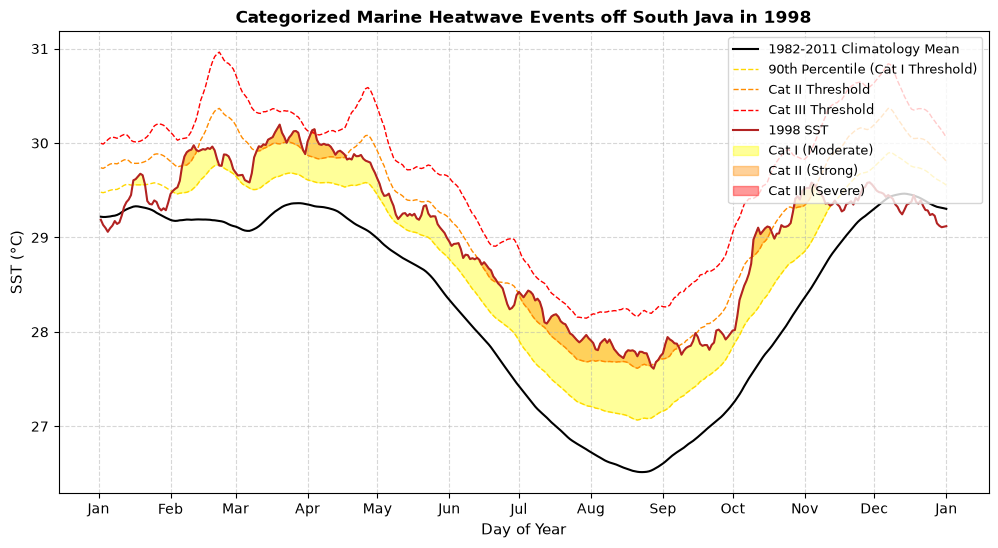

In [32]:
# Compute 1982-2011 Baseline Climatology
ds_baseline = ds_spatial_mean.sel(time=slice("1982-01-01", "2011-12-31"))

# Group by day of year
clim_mean = (
    ds_baseline.groupby("time.dayofyear")
    .mean()
    .sel(dayofyear=slice(1, 365))
    .rolling(dayofyear=10, center=True, min_periods=1)
    .mean()
)
clim_90p = (
    ds_baseline.groupby("time.dayofyear")
    .quantile(0.9)
    .sel(dayofyear=slice(1, 365))
    .rolling(dayofyear=10, center=True, min_periods=1)
    .mean()
)

# Select year to analyze (e.g., 2016 extreme year)
year_target = 1998
sst_target = (
    ds_spatial_mean.sel(time=str(year_target))
    .groupby("time.dayofyear")
    .mean()
    .sel(dayofyear=slice(1, 365))
)

doy = clim_mean["dayofyear"].data
t_mean = clim_mean.data
t_90p = clim_90p.data
t_obs = sst_target.data
delta = t_90p - t_mean

# Define Category Thresholds
cat_1 = t_90p
cat_2 = t_90p + delta
cat_3 = t_90p + 2 * delta
cat_4 = t_90p + 3 * delta

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(doy, t_mean, color="black", label="1982-2011 Climatology Mean")
ax.plot(
    doy,
    t_90p,
    color="gold",
    linestyle="--",
    linewidth=1,
    label="90th Percentile (Cat I Threshold)",
)
ax.plot(
    doy,
    cat_2,
    color="darkorange",
    linestyle="--",
    linewidth=1,
    label="Cat II Threshold",
)
ax.plot(
    doy, cat_3, color="red", linestyle="--", linewidth=1, label="Cat III Threshold"
)
ax.plot(doy, t_obs, color="firebrick", linewidth=1.5, label=f"{year_target} SST")

# Fill Category Colors
ax.fill_between(
    doy,
    np.maximum(t_obs, cat_1),
    cat_1,
    where=(t_obs > cat_1),
    color="yellow",
    alpha=0.4,
    label="Cat I (Moderate)",
)
ax.fill_between(
    doy,
    np.maximum(t_obs, cat_2),
    cat_2,
    where=(t_obs > cat_2),
    color="darkorange",
    alpha=0.4,
    label="Cat II (Strong)",
)
ax.fill_between(
    doy,
    np.maximum(t_obs, cat_3),
    cat_3,
    where=(t_obs > cat_3),
    color="red",
    alpha=0.4,
    label="Cat III (Severe)",
)

ax.set_ylabel("SST (°C)", fontsize=11)
ax.set_xlabel("Day of Year", fontsize=11)
ax.set_title(
    f"Categorized Marine Heatwave Events off South Java in {year_target}",
    fontsize=12,
    fontweight="bold",
)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper right", fontsize=9)

plt.gca().xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter("%b")
)  # Jan, Feb, ...
plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
plt.show()

Computing MHW indicators

In [33]:
## 7.1 Analysing a single year

def filter_short_true_runs(bool_array, min_length=5):
    """Filters out boolean True sequences shorter than min_length."""
    labels, num = label(bool_array)
    counts = np.bincount(labels)
    valid = np.isin(labels, np.where(counts >= min_length)[0])
    return valid & bool_array


# Single year calculation for 2016
year_test = 1998
sst_single = (
    ds_spatial_mean.sel(time=str(year_test))
    .groupby("time.dayofyear")
    .mean()
    .sel(dayofyear=slice(1, 365))
)

# Identify boolean days above 90th percentile
mhw_raw = sst_single.data > clim_90p.data
mhw_filtered = filter_short_true_runs(mhw_raw, min_length=5)

lbls, num_events = label(mhw_filtered)
event_counts = np.bincount(lbls)

print(f"--- MHW Summary for South Java ({year_test}) ---")
print(f"Number of MHW events: {num_events}")
if num_events > 0:
    print(f"Max duration of MHW events: {max(event_counts[1:])} days")
    print(f"Median duration of MHW events: {np.median(event_counts[1:]):.1f} days")

    sst_anom_mhw = np.where(
        mhw_filtered, sst_single.data - clim_mean.data, np.nan
    )
    print(
        f"Mean intensity of MHW events: +{np.nanmean(sst_anom_mhw):.2f} °C above 1982-2011 climatology"
    )
    print(
        f"Max intensity of MHW events: +{np.nanmax(sst_anom_mhw):.2f} °C above 1982-2011 climatology"
    )

--- MHW Summary for South Java (1998) ---
Number of MHW events: 3
Max duration of MHW events: 263 days
Median duration of MHW events: 20.0 days
Mean intensity of MHW events: +0.86 °C above 1982-2011 climatology
Max intensity of MHW events: +1.45 °C above 1982-2011 climatology


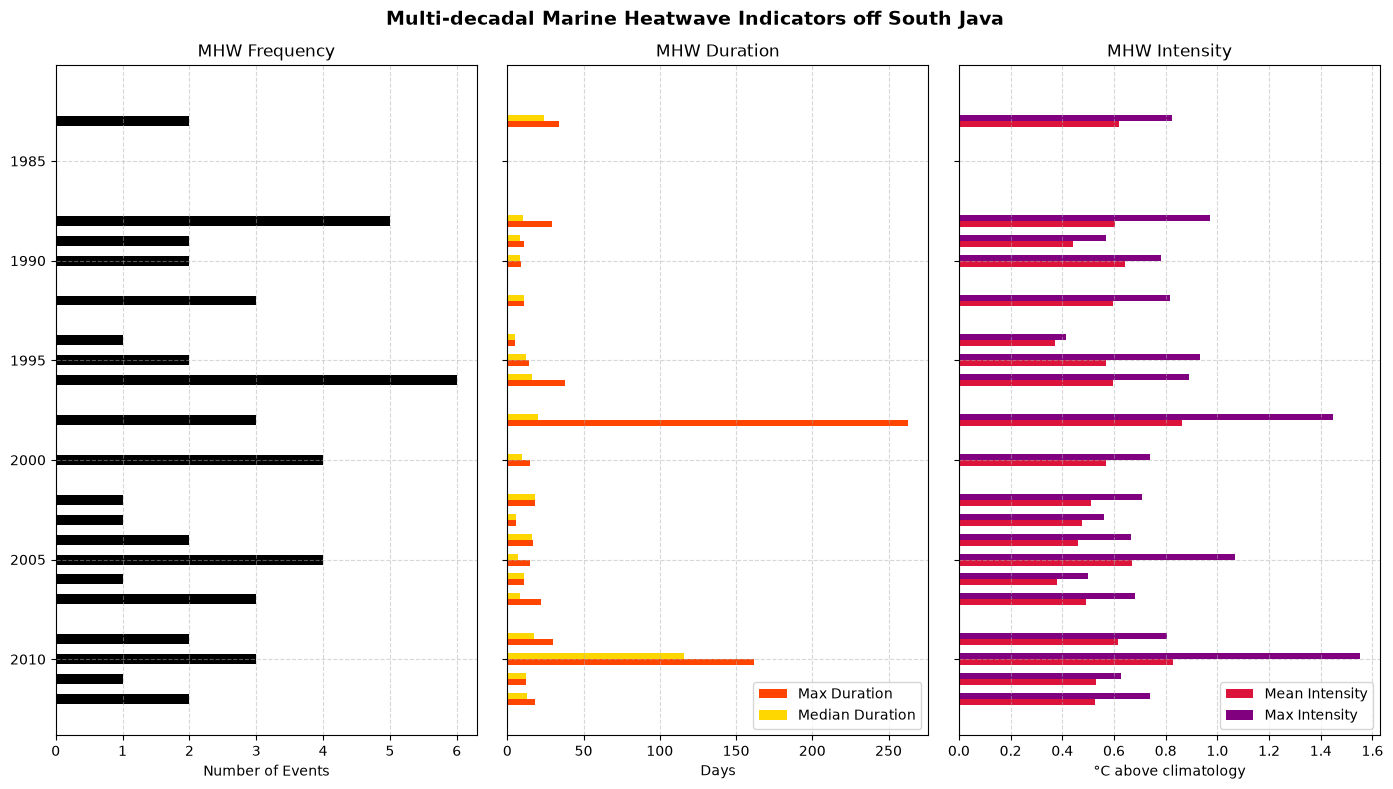

In [34]:
## 7.2 MHW events over the years

years_all = np.unique(ds_spatial_mean["time.year"].data)

num_events_list = []
max_dur_list = []
med_dur_list = []
avg_int_list = []
max_int_list = []

for yr in years_all:
    sst_yr = (
        ds_spatial_mean.sel(time=str(yr))
        .groupby("time.dayofyear")
        .mean()
        .sel(dayofyear=slice(1, 365))
    )

    mhw_bool = sst_yr.data > clim_90p.data
    mhw_filt = filter_short_true_runs(mhw_bool, min_length=5)

    lbls_yr, n_ev = label(mhw_filt)
    counts_yr = np.bincount(lbls_yr)

    num_events_list.append(n_ev)

    if n_ev > 0:
        max_dur_list.append(max(counts_yr[1:]))
        med_dur_list.append(np.median(counts_yr[1:]))

        anom_yr = np.where(mhw_filt, sst_yr.data - clim_mean.data, np.nan)
        avg_int_list.append(np.nanmean(anom_yr))
        max_int_list.append(np.nanmax(anom_yr))
    else:
        max_dur_list.append(0)
        med_dur_list.append(0)
        avg_int_list.append(0)
        max_int_list.append(0)

# Convert to numpy arrays
num_events_arr = np.array(num_events_list)
max_dur_arr = np.array(max_dur_list)
med_dur_arr = np.array(med_dur_list)
avg_int_arr = np.array(avg_int_list)
max_int_arr = np.array(max_int_list)

# Plotting 3-panel horizontal bar plot
fig, axes = plt.subplots(1, 3, figsize=(14, 8), sharey=True)

# Panel 1: Number of events
axes[0].barh(
    years_all, num_events_arr, height=0.5, color="black", label="Nb of Events"
)
axes[0].set_xlabel("Number of Events")
axes[0].set_title("MHW Frequency")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].invert_yaxis()

# Panel 2: Durations
axes[1].barh(
    years_all + 0.15,
    max_dur_arr,
    height=0.3,
    color="orangered",
    label="Max Duration",
)
axes[1].barh(
    years_all - 0.15,
    med_dur_arr,
    height=0.3,
    color="gold",
    label="Median Duration",
)
axes[1].set_xlabel("Days")
axes[1].set_title("MHW Duration")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(loc="lower right")

# Panel 3: Intensities
axes[2].barh(
    years_all + 0.15,
    avg_int_arr,
    height=0.3,
    color="crimson",
    label="Mean Intensity",
)
axes[2].barh(
    years_all - 0.15,
    max_int_arr,
    height=0.3,
    color="purple",
    label="Max Intensity",
)
axes[2].set_xlabel("°C above climatology")
axes[2].set_title("MHW Intensity")
axes[2].grid(True, linestyle="--", alpha=0.5)
axes[2].legend(loc="lower right")

plt.suptitle(
    "Multi-decadal Marine Heatwave Indicators off South Java",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

Exercises

1. In [Section 4](#4.-First-look-at-the-data), try exploring spatial SST maps for other extreme years, such as the **1997/1998 Super El Niño** or **2010 La Niña**!
2. Try picking a single coastal point off South Java (e.g., Chilacap / Pelabuhan Ratu) and extract its single-point SST timeseries.